Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Defining Known Data Points

In [2]:
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

Calculating Step Sizes and Setting Up the Tridiagonal System (from challenge 12)

In [3]:
def setup_tridiagonal_matrix(x, y):
    h = np.diff(x)  # Step sizes between data points
   
    # Initialize the tridiagonal matrix coefficients
    n = len(x)
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]           # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])  # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])    # Right-hand side vector
    return A, B, C, D

A,B,C,D = setup_tridiagonal_matrix(x,y)

Solving the Tridiagonal System

In [4]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

# Solve the system
X = thomas_algorithm(A, B, C, D)
print("Solution:", X)

M = np.zeros(len(x))
M[1:-1] = X

Solution: [-4.36363636  5.45454545 -5.45454545  4.36363636]


Evaluating the Spline at New Points

In [5]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
    (M[i] / (6*hi)) * dx_right**3 + # Term 1
    (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
    (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

Plotting the Results

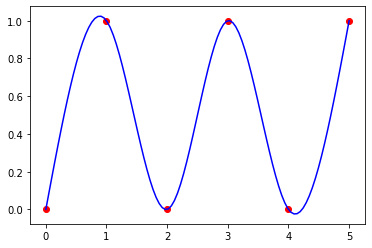

In [9]:
xs = np.linspace(0, 5, 100)
ys = [evaluate_spline(x, y, M, xi) for xi in xs]

plt.scatter(x, y, color = 'red')
plt.plot(xs, ys, color = 'blue')
plt.show()